<a href="https://colab.research.google.com/github/Jennymmmmm/lis5693/blob/main/lab-4/Lab-4_Jenny%20Min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


**Load the assigned dataset from your GitHub repo and determine the text data (features) and the target labels for the machine learning task.**

In [ ]:
import requests
import io
import pandas as pd

url = "https://raw.githubusercontent.com/Jennymmmmm/lis5693/main/lab-4/SMSSpamCollection"

response = requests.get(url)
response.raise_for_status()  # Raise an exception for HTTP errors

text = response.text

HTTPError: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/Jennymmmmm/lis5693/main/lab-4/SMSSpamCollection

In [ ]:
import pandas as pd

df = pd.read_csv(io.StringIO(text), sep="\t", header=None, names=["label", "message"])

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


The message column (shown below) was chosen as the feature because it contains the actual SMS text that the model will analyze. By looking at the words and patterns in the messages, the model could learn which types of messages are more likely to be spam. Moreover, the label column was selected as the target variable because it can tell us whether each message is spam or ham. In the classification process, the text messages will first be converted into numerical representations, and then a machine learning model will use those features to learn patterns and predict whether a new message is spam or ham.

In [ ]:
# Text features
features = df['message']

# Target labels
target = df['label']

# Label mapping
target_names = {
    'spam': '1',
    'ham': '0'
}

**Split the data into 70:30 ratio and perform text preprocessing.**

The dataset was split into training and testing sets using a 70:30 ratio. The training set was used to fit the preprocessing pipeline, while the test set was transformed using the same pipeline.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Replace missing values if there are any
X_train = X_train.fillna('')
X_test = X_test.fillna('')

# Text preprocessing pipeline
preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

# Check target labels
print(y_test.unique)

Training set has 3900 samples.
Testing set has 1672 samples.
Preprocessing training data...
Preprocessing test data...
<bound method Series.unique of 3245     ham
944      ham
1044     ham
2484     ham
812      ham
        ... 
2505     ham
2525    spam
4975     ham
650     spam
4463     ham
Name: label, Length: 1672, dtype: object>


In [ ]:
y_test.unique()

array([1, 0])

**Train 3 classifiers of your choice using the training data. Evaluate and compare their performance using appropriate evaluation metrics such as accuracy, precision, recall, and F1-score.**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Initialize classifiers
nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [ ]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)

In [ ]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.668693009118541
SVM Accuracy: 0.9057750759878419
LR Accuracy: 0.8915906788247214
ADA Accuracy: 0.9138804457953394
RF Accuracy: 0.8389057750759878


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Naive Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions, pos_label='spam'))
print("Recall:", recall_score(y_test, nb_predictions, pos_label='spam'))
print("F1-score:", f1_score(y_test, nb_predictions, pos_label='spam'))

print("\nSVM Performance:")
print("Accuracy:", accuracy_score(y_test, svm_predictions))
print("Precision:", precision_score(y_test, svm_predictions, pos_label='spam'))
print("Recall:", recall_score(y_test, svm_predictions, pos_label='spam'))
print("F1-score:", f1_score(y_test, svm_predictions, pos_label='spam'))

print("\nLogistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions, pos_label='spam'))
print("Recall:", recall_score(y_test, lr_predictions, pos_label='spam'))
print("F1-score:", f1_score(y_test, lr_predictions, pos_label='spam'))

Naive Bayes Performance:
Accuracy: 0.9629186602870813
Precision: 1.0
Recall: 0.7232142857142857
F1-score: 0.8393782383419689

SVM Performance:
Accuracy: 0.9922248803827751
Precision: 0.9861751152073732
Recall: 0.9553571428571429
F1-score: 0.9705215419501134

Logistic Regression Performance:
Accuracy: 0.97188995215311
Precision: 0.988950276243094
Recall: 0.7991071428571429
F1-score: 0.8839506172839506


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)

svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [ ]:
print("Best SVM Parameters")
print(svm_best.best_params_)

print("Best Cross-validation Score")
print(svm_best.best_score_)

Best SVM Parameters
{'C': 10}
Best Cross-validation Score
0.9828205128205129


In [ ]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy")
print(np.mean(best_svm_predictions == y_test))

Best SVM Accuracy
0.9922248803827751


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, svm_predictions, target_names=target_names))

              precision    recall  f1-score   support

        spam       0.99      1.00      1.00      1448
         ham       0.99      0.96      0.97       224

    accuracy                           0.99      1672
   macro avg       0.99      0.98      0.98      1672
weighted avg       0.99      0.99      0.99      1672



Summary: After training and evaluating three classifiers, the results showed that the Support Vector Machine (SVM) performed the best among the models. It achieved the highest accuracy, precision, recall, and F1-score compared to Naive Bayes and Logistic Regression. This likely occurred because SVM is effective at handling high-dimensional text data created by the TF-IDF features and can better separate spam and non-spam messages. While Naive Bayes also performed well and is commonly used for text classification, SVM provided slightly better overall performance in distinguishing between spam and legitimate messages in this dataset.

**Next, generate a confusion matrix for the best-performing classifier and explain the results in your own words. Interpret what the values in the matrix represent in terms of correct and incorrect classifications. **

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for the best classifier (SVM)
svm_cm = confusion_matrix(y_test, svm_predictions)

print("Confusion Matrix for Best Classifier (SVM):")
print(svm_cm)

Confusion Matrix for Best Classifier (SVM):
[[1445    3]
 [  10  214]]


(array([0.5, 1.5]), [Text(0.5, 0, 'spam'), Text(1.5, 0, 'ham')])

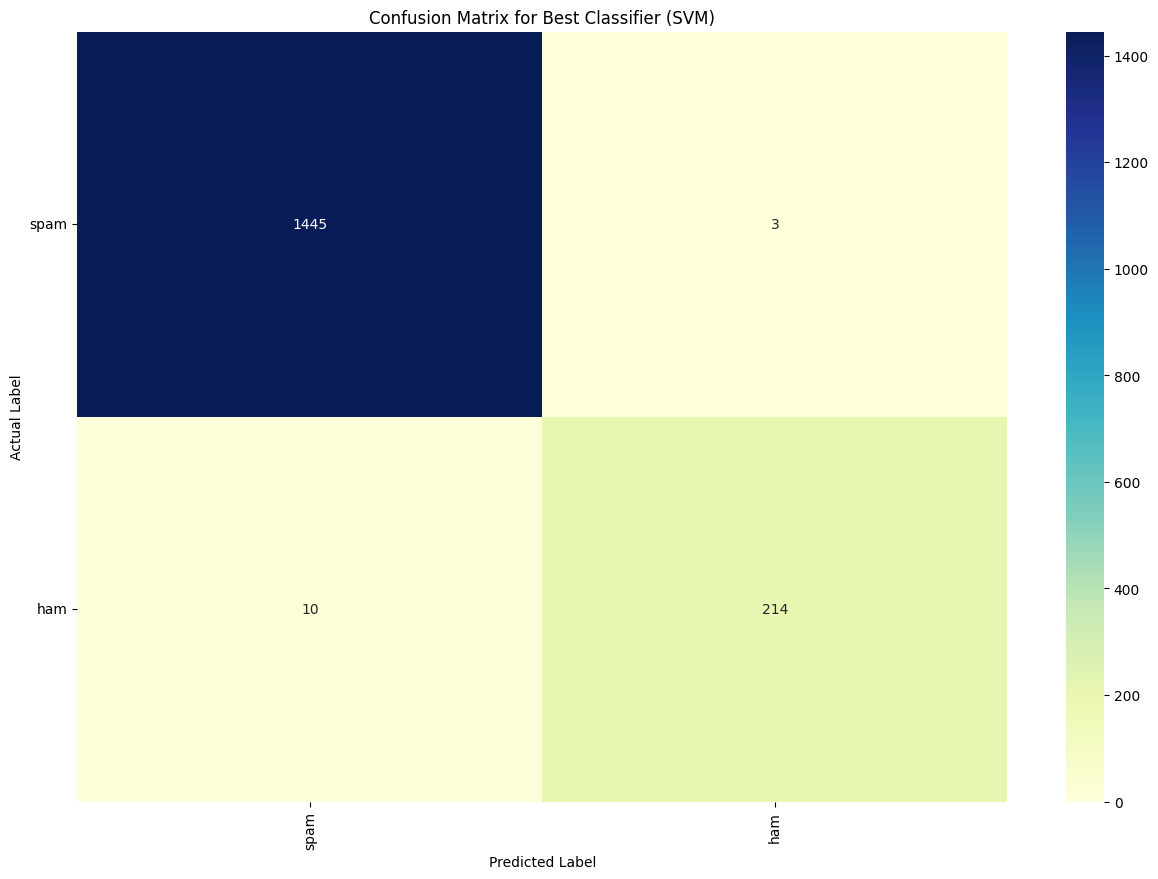

In [ ]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix for best classifier (SVM)
conf_matrix = confusion_matrix(y_test, svm_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")

plt.title("Confusion Matrix for Best Classifier (SVM)")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")

plt.yticks(rotation=0)
plt.xticks(rotation=90)

The confusion matrix helped me to see how well the model predicted spam and ham messages. The numbers on the diagonal of the matrix represent correct predictions, while the numbers outside the diagonal represent mistakes made by the model. For example, the top-left value shows how many ham messages were predicted, and the bottom-right value shows how many spam messages were correctly predicted as spam.

The other two values represent errors. The top-right value shows ham messages that were incorrectly classified as spam, and the bottom-left value shows spam messages that were incorrectly classified as ham. Ideally, we want these numbers to be as small as possible because they indicate misclassifications.

In this case, most of the messages were correctly classified, which is why most of the values appear on the diagonal of the matrix. Only a small number of messages were misclassified, suggesting that the model does a good job distinguishing between spam and legitimate messages.

In [ ]:
import pandas as pd
import requests
import io

url = "https://raw.githubusercontent.com/Jennymmmmm/lis5693/main/lab-4/pseudo"

response = requests.get(url)
response.raise_for_status()

text = response.text

pseudo_df = pd.read_csv(io.StringIO(text))

print(pseudo_df.head())

   label                                            message
0    NaN          Hey are we still meeting for lunch today?
1    NaN  Win a FREE vacation now! Click the link to cla...
2    NaN  Reminder: Your dentist appointment is tomorrow...
3    NaN  Congratulations! You have been selected to rec...
4    NaN         Can you call me when you get this message?


In [ ]:
pseudo_features = pseudo_df["message"].fillna("")

pseudo_preprocessed = preprocessing.transform(pseudo_features)

predicted_labels = svm_classifier.predict(pseudo_preprocessed)

pseudo_df["predicted_label"] = predicted_labels

print(pseudo_df.head())

   label                                            message predicted_label
0    NaN          Hey are we still meeting for lunch today?             ham
1    NaN  Win a FREE vacation now! Click the link to cla...            spam
2    NaN  Reminder: Your dentist appointment is tomorrow...             ham
3    NaN  Congratulations! You have been selected to rec...            spam
4    NaN         Can you call me when you get this message?             ham


In [ ]:
pseudo_df.to_csv("predicted.csv", index=False)

In [ ]:
from google.colab import files
files.download("predicted.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Briefly share your insights about the model’s performance.**

It was interesting to run the analysis using the pseudo dataset, and the process felt efficient since the machine learning model had already been trained. Looking at the results, the model appeared to perform quite accurately, which made the experience of using machine learning both engaging and exciting. Most promotional or suspicious messages, such as those offering prizes or asking users to click links, were correctly classified as spam. At the same time, regular conversational messages were generally labeled as ham. Overall, the model demonstrated strong performance in distinguishing between spam and legitimate messages.

**Reflection**

Since this was my first time exploring and learning about machine learning, the first few steps were quite challenging because there were many lines of code to understand. However, once I understood the structure of the code, the process became much smoother. Training the model and applying it to the pseudo dataset worked well, and it was satisfying to see the model successfully generate predictions.However, each time I ran the code and saw it load successfully without errors, it felt very rewarding and exciting. It was also interesting to see that new data could be processed using the trained model, which made me start thinking about how this approach could be used in research. I am particularly interested in studying public perceptions of early childhood teachers, and I would like to explore using large-scale data from platforms such as Facebook or Twitter to analyze these perceptions. This experience encouraged me to dive deeper into machine learning and think about how I could apply these methods to my own research in the future.